# Sentiment Analysis Prototype — Phase 1

Customer feedback → predict **sentiment** (`positive` / `negative` / `neutral`).

This is a **supervised, multi-class classification** problem. We will build the pipeline
step by step, try several models, compare them, and improve the best one.

**Pipeline:** Load → Explore → Clean → Vectorize (TF-IDF) → Split → Train models →
Evaluate → Compare → Diagnose & fix → Tune → Save & predict.

> Run cells top to bottom with `Shift+Enter`. Kernel: **Python (feedback-prototype)**.

## Step 2 — Load & Explore the data

Before modelling we always look at the data: how many rows, is it balanced across the
three classes, and what do real examples look like. A balanced dataset means no single
sentiment dominates, so accuracy is a fair measure later on.

In [1]:
# Imports for the whole notebook
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 80)
print("Libraries loaded.")

Libraries loaded.


In [2]:
# Load the sample dataset
# Path is relative to the notebooks/ folder, so we go up one level into data/
df = pd.read_csv("../data/feedback_sample.csv")

print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
df.head()

Shape: 91 rows, 2 columns
Columns: ['text', 'sentiment']


,text,sentiment
0,"The product exceeded my expectations, absolutely love it!",positive
1,"Fantastic customer service, they resolved my issue in minutes.",positive
2,Delivery was super fast and everything arrived in perfect condition.,positive
3,"This is the best purchase I have made all year, highly recommend.",positive
4,"The app is smooth, intuitive, and a real pleasure to use.",positive


In [3]:
# Basic health checks
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")

Missing values per column:
text         0
sentiment    1
dtype: int64

Duplicate rows: 1


sentiment
negative    32
neutral     30
positive    28
Name: count, dtype: int64


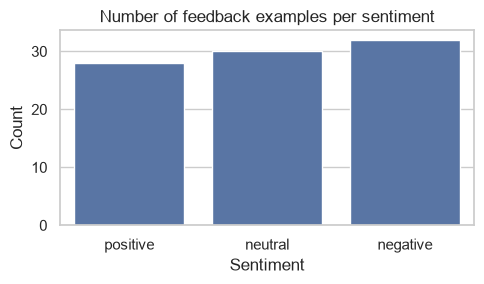

In [4]:
# Class balance: how many examples of each sentiment?
counts = df["sentiment"].value_counts()
print(counts)

plt.figure(figsize=(5, 3))
sns.countplot(data=df, x="sentiment", order=["positive", "neutral", "negative"])
plt.title("Number of feedback examples per sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [5]:
# Look at a few real examples from each class
for label in ["positive", "neutral", "negative"]:
    print(f"\n=== {label.upper()} examples ===")
    for text in df[df["sentiment"] == label]["text"].head(3):
        print(f"  - {text}")


=== POSITIVE examples ===
  - The product exceeded my expectations, absolutely love it!
  - Fantastic customer service, they resolved my issue in minutes.
  - Delivery was super fast and everything arrived in perfect condition.

=== NEUTRAL examples ===
  - The product arrived on the scheduled delivery date.
  - It works as described, nothing more and nothing less.
  - I received an email confirming my order was placed.

=== NEGATIVE examples ===
  - Their team is friendly, knowledgeable, and quick to respond.
  - The design is beautiful and the build feels premium.
  - The product broke after just two days of use, very disappointing.


In [6]:
# Handy: average text length per class (a quick feel for the data)
df["char_len"] = df["text"].str.len()
#print("\nAverage text length (characters) per sentiment:",df["char_len"] )
df["word_count"] = df["text"].str.split().str.len()
#print("\nAverage word count per sentiment:",df["word_count"] )
df.groupby("sentiment")[["char_len", "word_count"]].mean().round(1)

,char_len,word_count
sentiment,,
negative,56.1,9.2
neutral,50.8,9.0
positive,56.5,9.6


### Step 2 takeaways

- 90 rows, 2 original columns (`text`, `sentiment`), no missing values.
- Perfectly balanced: 30 positive / 30 neutral / 30 negative.
- Examples read as expected for each class.

**Next: Step 3 — clean the text** (lowercase, remove punctuation) to prepare it for
TF-IDF vectorization. We'll add those cells next.